,size
count,47955.000000
mean,24540.576165
std,11236.377367
min,10001.000000
25%,14745.000000
50%,22039.000000
75%,32834.000000
max,49999.000000


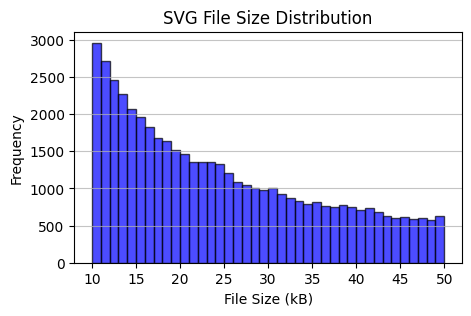

,size
count,1000.000000
mean,29998.631000
std,11552.555762
min,10036.000000
25%,20005.250000
50%,29988.500000
75%,39983.250000
max,49975.000000


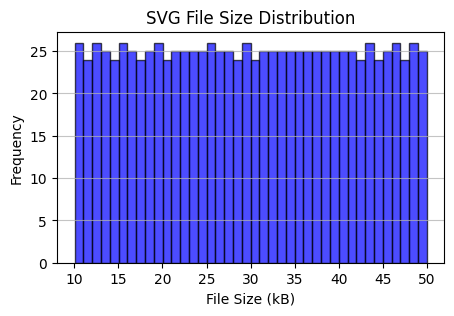

Benchmarking:   2%|▏         | 21/1000 [00:23<18:25,  1.13s/it, filename=157533.svg, operation=mask]     


KeyboardInterrupt: 

In [3]:
# ruff: noqa: T201, S311

import contextlib
import copy
import pathlib
import random
import time
import warnings
from collections.abc import Generator

import cache_pandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
from typing_extensions import Callable, Final, cast

import svglab


SOURCE_DIR: Final = pathlib.Path("~/Downloads/freesvg").expanduser()
MIN_SIZE: Final = 10 * 1000  # 10 KB
MAX_SIZE: Final = 50 * 1000  # 50 KB
SAMPLES: Final = 1000
SEED: Final = 42
OUTPUT: Final = pathlib.Path("output.csv")
BLACKLIST: Final = {
    "101126.svg",
    "109816.svg",
    "143300.svg",
    "194135.svg",
    "33377.svg",
    "33382.svg",
    "61757.svg",
    "86698.svg",
}

FORMATTER: Final = svglab.Formatter(
    color_mode="original",
    coordinate_precision=svglab.FloatPrecisionSettings(fallback=1),
    indent=2,
    large_number_scientific_threshold=None,
    path_data_coordinates="absolute",
    path_data_shorthand_curve_commands="original",
    path_data_shorthand_line_commands="original",
    small_number_scientific_threshold=None,
    spaces_around_attrs=False,
    spaces_around_function_args=False,
    strip_leading_zero=False,
    xmlns="original",
)


random.seed(SEED)
rng: Final = np.random.default_rng(SEED)


@contextlib.contextmanager
def _timer() -> Generator[Callable[[], float]]:
    start = time.perf_counter()

    def elapsed() -> float:
        end = time.perf_counter()
        return (end - start) * 1000

    yield elapsed


def _has_compatible_lengths(element: svglab.Element) -> bool:
    for attr in element.standard_attrs().values():
        if not isinstance(attr, svglab.Length):
            continue

        if attr.unit not in [None, "px", "%", "Q"]:
            return False

    return all(
        _has_compatible_lengths(child)
        for child in element.find_all(recursive=False)
    )


def _should_include(name: str) -> bool:
    if name in BLACKLIST:
        return False

    with (SOURCE_DIR / name).open("r") as f:
        try:
            svg = svglab.parse_svg(f)

            return _has_compatible_lengths(svg)
        except Exception as e:  # noqa: BLE001
            warnings.warn(f"Failed to parse SVG {name}: {e}", stacklevel=2)
            return False


def _get_viewbox(svg: svglab.Svg) -> tuple[float, float, float, float]:
    if svg.viewBox is not None:
        return svg.viewBox

    w = float(svg.width) if svg.width is not None else 100
    h = float(svg.height) if svg.height is not None else 100

    return (0, 0, w, h)


@cache_pandas.cache_to_csv("raw.csv")
def _load_data() -> pd.DataFrame:
    data = pd.DataFrame(
        (
            (path.name, path.stat().st_size)
            for path in tqdm.tqdm(
                SOURCE_DIR.glob("*.svg"), desc="Loading SVGs"
            )
        ),
        columns=["filename", "size"],
    )
    return data.sort_values("filename")


@cache_pandas.cache_to_csv("good_size.csv")
def _filter_size(data: pd.DataFrame) -> pd.DataFrame:
    return data[(data["size"] > MIN_SIZE) & (data["size"] < MAX_SIZE)]


@cache_pandas.cache_to_csv("sampled.csv")
def _sample_data(data: pd.DataFrame) -> pd.DataFrame:
    bins = np.linspace(MIN_SIZE, MAX_SIZE, SAMPLES + 1)
    samples: list[pd.DataFrame] = []

    for i in (pbar := tqdm.tqdm(range(SAMPLES), desc="Sampling")):
        lower: float = bins[i]
        upper: float = bins[i + 1]

        mask = (data["size"] >= lower) & (data["size"] < upper)
        bin_data = data[mask]

        while True:
            sample = bin_data.sample(n=1, random_state=rng)
            filename: str = sample["filename"].to_numpy()[0]
            pbar.set_postfix(filename=filename)

            if _should_include(filename):
                samples.append(sample)
                break

    return pd.concat(samples, ignore_index=True)


@cache_pandas.cache_to_csv("perf.csv")
def _run_benchmarks(data: pd.DataFrame) -> pd.DataFrame:
    data = data.sample(frac=1, random_state=rng).reset_index(drop=True)

    for row in (
        pbar := tqdm.tqdm(
            data.itertuples(index=False),
            total=len(data),
            desc="Benchmarking",
        )
    ):
        filename = cast(str, row.filename)

        with (SOURCE_DIR / filename).open("r") as f:
            markup = f.read()

        pbar.set_postfix(filename=filename, operation="parse")

        with _timer() as get_elapsed:
            svg = svglab.parse_svg(markup)
            data.loc[data["filename"] == filename, "parse_time"] = (
                get_elapsed()
            )

        x_min, y_min, w, h = _get_viewbox(svg)

        if svg.width is None:
            svg.width = svglab.Length(w)

        if svg.height is None:
            svg.height = svglab.Length(h)

        pbar.set_postfix(filename=filename, operation="reify")
        svg_copy = copy.deepcopy(svg)

        with _timer() as get_elapsed:
            svg_copy.set_viewbox((x_min, y_min, 2 * w, 2 * h))
            svg_copy.reify()
            data.loc[data["filename"] == filename, "reify_time"] = (
                get_elapsed()
            )

        pbar.set_postfix(filename=filename, operation="mask")
        svg_copy = copy.deepcopy(svg)

        element = random.choice(
            [
                *svg_copy.find_all(
                    svglab.GraphicsElement, recursive=False
                ),
                *svg_copy.find_all(
                    svglab.ContainerElement, recursive=False
                ),
            ]
        )

        with _timer() as get_elapsed:
            element.get_mask(visible_only=True, width=100, height=100)
            data.loc[data["filename"] == filename, "mask_time"] = (
                get_elapsed()
            )

        pbar.set_postfix(filename=filename, operation="serialize")

        with _timer() as get_elapsed:
            svg.to_xml(formatter=FORMATTER)
            data.loc[data["filename"] == filename, "serialize_time"] = (
                get_elapsed()
            )

    return data


data = _load_data()
data = _filter_size(data)

display(data.describe())

plt.figure(figsize=(5, 3))
plt.hist(
    data["size"] / 1000,
    bins=(MAX_SIZE - MIN_SIZE) // 1000,
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
plt.title("SVG File Size Distribution")
plt.xlabel("File Size (kB)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

data = _sample_data(data)

display(data.describe())

plt.figure(figsize=(5, 3))
plt.hist(
    data["size"] / 1000,
    bins=(MAX_SIZE - MIN_SIZE) // 1000,
    color="blue",
    alpha=0.7,
    edgecolor="black",
)
plt.title("SVG File Size Distribution")
plt.xlabel("File Size (kB)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

data = _run_benchmarks(data)
display(data.describe())

plt.figure(figsize=(10, 7))
for column in ["parse_time", "reify_time", "mask_time", "serialize_time"]:
    plt.plot(data["size"] / 1000, data[column], linestyle="-", alpha=0.7)
plt.title("SVG Processing Times vs File Size")
plt.xlabel("File Size (kB)")
plt.ylabel("Time (ms)")
plt.legend(["Parse", "Reify", "Mask", "Serialize"])
plt.grid()
plt.show()

plt.figure(figsize=(4, 4))
plt.pie(
    data[
        ["parse_time", "reify_time", "mask_time", "serialize_time"]
    ].mean(),
    labels=["Parse", "Reify", "Mask", "Serialize"],
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Average Processing Time Distribution")
plt.axis("equal")
plt.show()

# do the same as above, but scatter plot
plt.figure(figsize=(10, 7))
for column in ["parse_time", "reify_time", "mask_time", "serialize_time"]:
    plt.scatter(data["size"] / 1000, data[column], alpha=0.7, label=column)
plt.title("SVG Processing Times vs File Size (Scatter)")
plt.xlabel("File Size (kB)")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid()
plt.show()